### Analysis - Continuous Tracking

In [91]:
import numpy as np
from scipy.signal import correlate, correlation_lags
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import pandas as pd

#### Cross Correlogram

In [92]:

def compute_cross_correlogram(reference_signal, effector_signal, sampling_rate, max_lag_seconds) -> tuple:
    """Compute cross-correlogram and extract metrics between two signals.
    Parameters:
        reference_signal (np.ndarray): The reference signal (e.g., effector movement).
        effector_signal (np.ndarray): The signal to compare against the reference (e.g., cursor movement).
        sampling_rate (float): Sampling rate of the signals in Hz.
        max_lag_seconds (float): Maximum lag to consider for the cross-correlogram in seconds.
    Returns:
        lags (np.ndarray): Array of lag times in seconds.
        correlation_scores (np.ndarray): Cross-correlation values at each lag.
        optimal_lag_seconds (float): Lag time at which the correlation is maximal.
        peak_correlation (float): Maximum correlation value.
        width (float): Full Width at Half Maximum (FWHM) of the correlation peak.
        # area (float): Area under the cross-correlogram curve within the max lag window.
    """
    # STEP 1: Center the signals
    effector_centered = effector_signal - np.mean(effector_signal)
    reference_centered = reference_signal - np.mean(reference_signal)
    
    # STEP 2 & 3: Compute raw cross-correlation using SciPy
    # This automatically computes all possible lags
    raw_corr = correlate(effector_centered, reference_centered, mode='full')
    all_lags = correlation_lags(len(effector_centered), len(reference_centered), mode='full')
    
    # Crop to your specified max_lag_seconds window
    max_lag_frames = int(max_lag_seconds * sampling_rate)
    window_mask = (all_lags >= -max_lag_frames) & (all_lags <= max_lag_frames)
    
    lags_frames = all_lags[window_mask]
    raw_corr_window = raw_corr[window_mask]
    lags = lags_frames / sampling_rate
    
    # STEP 4: Proper Pearson Correlation Normalization per lag
    # We must calculate standard deviations based on the exact overlapping slices
    correlation_scores = np.zeros_like(raw_corr_window, dtype=float)
    N = len(effector_signal)
    
    for i, lag in enumerate(lags_frames):
        if lag < 0:
            e_slice = effector_centered[-lag:]
            r_slice = reference_centered[:N + lag]
        else:
            e_slice = effector_centered[:N - lag]
            r_slice = reference_centered[lag:]
            
        denom = np.std(e_slice) * np.std(r_slice) * len(e_slice)
        if denom > 0:
            correlation_scores[i] = np.sum(e_slice * r_slice) / denom

    # STEP 5: Extract Metrics safely
    peak_index = np.argmax(correlation_scores)
    peak_correlation = correlation_scores[peak_index]
    optimal_lag_seconds = lags[peak_index]
    
    # Calculate Width (FWHM) properly relative to the baseline/peak floor
    half_max_threshold = peak_correlation / 2.0
    
    # Find where the curve drops below half-max on the left and right sides of the peak
    left_side = correlation_scores[:peak_index]
    right_side = correlation_scores[peak_index:]
    
    # Find closest crossing points
    left_idx = np.where(left_side < half_max_threshold)[0]
    right_idx = np.where(right_side < half_max_threshold)[0]
    
    idx_start = left_idx[-1] if len(left_idx) > 0 else 0
    idx_end = peak_index + right_idx[0] if len(right_idx) > 0 else len(correlation_scores) - 1
    
    width = lags[idx_end] - lags[idx_start]
    
    # Area under the curve (using Trapezoidal rule within your max lag window)
    # area = np.trapz(correlation_scores, lags)
    
    return lags, correlation_scores, optimal_lag_seconds, peak_correlation, width #, area


In [93]:
def average_cross_correlogram(block_metrics: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    """Average trial-level cross-correlograms onto a shared lag grid.
    
    Parameters:
    block_metrics (pd.DataFrame): DataFrame containing trial-level metrics for a block.

    Returns:
    tuple: A tuple containing common lags and averaged correlation scores for cursor and gaze signals.
    """
    # Convert lists of lags and scores into numpy arrays for easier manipulation
    lags_list_cursor = [np.asarray(lags) for lags in block_metrics['lags_cursor']]
    score_list_cursor = [np.asarray(scores) for scores in block_metrics['correlation_scores_cursor']]
    lags_list_gaze = [np.asarray(lags) for lags in block_metrics['lags_gaze']]
    score_list_gaze = [np.asarray(scores) for scores in block_metrics['correlation_scores_gaze']]

    # Check if all trials have the same lag grid, if so, return the average directly
    reference_lags = lags_list_cursor[0]
    same_grid = all(
        len(lags) == len(reference_lags) and np.allclose(lags, reference_lags)
        for lags in lags_list_cursor[1:]
    )
    if same_grid:
        return reference_lags, np.vstack(score_list_cursor).mean(axis=0), lags_list_gaze[0], np.vstack(score_list_gaze).mean(axis=0)

    # If not, interpolate onto a common lag grid
    common_min_cursor = max(lags[0] for lags in lags_list_cursor)
    common_max_cursor = min(lags[-1] for lags in lags_list_cursor)
    common_length_cursor = min(len(lags) for lags in lags_list_cursor)
    common_lags_cursor = np.linspace(common_min_cursor, common_max_cursor, common_length_cursor)
    interpolated_scores_cursor = np.vstack([
        np.interp(common_lags_cursor, lags, scores)
        for lags, scores in zip(lags_list_cursor, score_list_cursor)
    ])

    # Repeat the same process for gaze signals
    common_min_gaze = max(lags[0] for lags in lags_list_gaze)
    common_max_gaze = min(lags[-1] for lags in lags_list_gaze)
    common_length_gaze = min(len(lags) for lags in lags_list_gaze)
    common_lags_gaze = np.linspace(common_min_gaze, common_max_gaze, common_length_gaze)
    interpolated_scores_gaze = np.vstack([
        np.interp(common_lags_gaze, lags, scores)
        for lags, scores in zip(lags_list_gaze, score_list_gaze)
    ])

    return common_lags_cursor, interpolated_scores_cursor.mean(axis=0), common_lags_gaze, interpolated_scores_gaze.mean(axis=0)


In [94]:


def plot_cross_correlogram(fig, axes, lags, correlation_scores, optimal_lag_seconds, peak_correlation, width, signal_name) -> None:
    """Plots a modernized cross-correlogram comparing target and tracking signals."""
    
    # Setup color palette by signal type
    is_cursor = signal_name.lower() == 'cursor'
    main_color = '#2B6CB0' if is_cursor else '#DD6B20'
    fill_color = '#4299E1' if is_cursor else '#ED8936'
    peak_line_color = '#E53E3E'
    half_max_val = peak_correlation / 2
    
    # Plot core correlation signals and baseline
    axes.plot(lags, correlation_scores, color=main_color, linewidth=2.2, label='Cross-Correlogram', zorder=3)
    axes.axhline(0, color='#CBD5E0', linestyle='-', linewidth=0.8, zorder=1)
    
    # Plot metrics (Optimal Lag and Half-Max threshold)
    axes.axvline(optimal_lag_seconds, color=peak_line_color, linestyle=':', linewidth=1.5, 
                 label=f'Optimal Lag: {optimal_lag_seconds:.3f}s', zorder=2)
    axes.plot(optimal_lag_seconds, peak_correlation, marker='o', markersize=7, 
              color=peak_line_color, markeredgecolor='white', markeredgewidth=1.2, zorder=5)
    axes.axhline(half_max_val, color='#718096', linestyle='--', linewidth=1.2, alpha=0.8,
                 label=f'Half-Max: {half_max_val:.2f}', zorder=2)
    
    # Shade FWHM Width area
    width_condition = (lags >= optimal_lag_seconds - width/2) & (lags <= optimal_lag_seconds + width/2)
    axes.fill_between(lags, 0, correlation_scores, where=width_condition, 
                      color=fill_color, alpha=0.15, label=f'Width (FWHM): {width:.3f}s', zorder=2)
    
    # Titles, Labels, and Layout styling
    axes.set_title(f'Target vs. {signal_name}', fontsize=12, fontweight='bold', pad=14, color='#2D3748')
    axes.set_xlabel('Lag Time (seconds)', fontsize=10, fontweight='medium', labelpad=6, color='#4A5568')
    axes.set_ylabel('Correlation Coefficient (r)', fontsize=10, fontweight='medium', labelpad=6, color='#4A5568')
    
    axes.set_xlim(lags[0], lags[-1])
    axes.set_ylim(-1.05, 1.05)
    axes.grid(True, linestyle='--', color='#E2E8F0', alpha=0.7, zorder=0)
    
    # Clean up outer borders
    for spine in ['top', 'right']:
        axes.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        axes.spines[spine].set_color('#CBD5E0')
        
    axes.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#E2E8F0', framealpha=0.9, fontsize=9)


#### Position error

In [95]:
def compute_position_error(reference_position_signal, effector_position_signal) -> float:
    """Compute the mean Euclidean distance between the reference and effector signals.
    
    Parameters:
    reference_position_signal (np.ndarray): The reference position signal array.
    effector_position_signal (np.ndarray): The effector position signal array.

    Returns:
    float: The mean Euclidean distance between the reference and effector signals.
    """
    return np.mean(np.sqrt((reference_position_signal - effector_position_signal) ** 2))

#### Velocity Error (eye & cursor)

In [96]:
def compute_velocity_error(reference_velocity_signal, effector_velocity_signal) -> float:
    """Compute the mean absolute difference in velocity between the reference and effector signals.
    
    Parameters:
    reference_velocity_signal (np.ndarray): The reference velocity signal array.
    effector_velocity_signal (np.ndarray): The effector velocity signal array.

    Returns:
    float: The mean absolute velocity error between the reference and effector signals.
    """
    
    # Compute mean absolute velocity error
    return np.mean(np.abs(reference_velocity_signal - effector_velocity_signal))

#### Position Variance (eye & cursor)

In [97]:
def compute_position_variance(position_signal: np.ndarray) -> float:
    """Compute the variance of the position signal to measure how much it spreads out or drifts around its own average trajectory.
    
    Parameters:
    position_signal (np.ndarray): The position signal array.

    Returns:
    float: The variance of the position signal.
    """
    return np.var(position_signal)

#### Saccade rate (eye)

In [98]:
def compute_saccade_rate(signal: np.ndarray) -> float:
    """Compute the saccade rate by counting the eyelink saccade messages.
    
    Parameters:
    signal (np.ndarray): The position signal array.
    sampling_rate (float): The sampling rate of the signal in Hz.
    velocity_threshold (float): The velocity threshold to identify saccades.

    Returns:
    float: The saccade rate in saccades per second.
    """
    # TODO count the saccades
    return 0.0  # Placeholder return value; implement saccade counting logic here


#### Gain (eye)

In [99]:
def compute_gain_eye(reference_velocity_signal_x, reference_velocity_signal_y, effector_velocity_signal_x, effector_velocity_signal_y) -> float:
    """Compute the gain of the eye movement by comparing the amplitude of the effector signal to the reference signal.
    
    Parameters:
    reference_velocity_signal_x (np.ndarray): The reference velocity signal array for the x-axis.
    reference_velocity_signal_y (np.ndarray): The reference velocity signal array for the y-axis.
    effector_velocity_signal_x (np.ndarray): The effector velocity signal array for the x-axis.
    effector_velocity_signal_y (np.ndarray): The effector velocity signal array for the y-axis.

    Returns:
    float: The gain of the eye movement.
    """
    # Compute the 2d magnitude of the reference and effector signals
    reference_magnitude = np.sqrt(reference_velocity_signal_x**2 + reference_velocity_signal_y**2)
    effector_magnitude = np.sqrt(effector_velocity_signal_x**2 + effector_velocity_signal_y**2)
    
    # Return the gain
    return effector_magnitude / reference_magnitude if np.mean(reference_magnitude) > 0 else 0.0

### compute all metrics for each participant

In [100]:
def compute_one_trial(
    trial_data: pd.DataFrame,
    sampling_rate,
    max_lag_seconds,
    velocity_threshold
) -> dict:
    """Compute all relevant metrics for one trial dataframe. (for cursor and gaze signals)
    
    Parameters:
    trial_data (pd.DataFrame): The rows for a single trial.
    sampling_rate (float): The sampling rate of the signals in Hz.
    max_lag_seconds (float): Maximum lag to consider for the cross-correlogram in seconds.
    velocity_threshold (float): The velocity threshold to identify saccades.

    Returns:
    dict: A dictionary containing all computed metrics for the trial.
    whats in the return dictionary:
    # cursor metrics in x
    - lags_cursor_x: the lags for the cursor signal in the x direction
    - correlation_scores_cursor_x: the correlation scores for the cursor signal in the x direction
    - optimal_lag_seconds_cursor_x: the optimal lag in seconds for the cursor signal in the x direction
    - peak_correlation_cursor_x: the peak correlation for the cursor signal in the x direction
    - width_cursor_x: the width of the correlation peak for the cursor signal in the x direction
    - position_error_cursor_x: the position error for the cursor signal in the x direction
    - velocity_error_cursor_x: the velocity error for the cursor signal in the x direction
    - position_variance_cursor_x: the position variance for the cursor signal in the x direction

    # cursor metrics in y
    - same thing

    # gaze metrics in x
    - same thing

    # gaze metrics in y
    - same thing

    # other eye metrics
    - saccade_rate: the saccade rate for the gaze signal
    - gain_eye: the gain of the eye movement for the gaze signal

    """
    # Clean the trial data by dropping rows with NaN values in the relevant columns
    cleaned_trial = trial_data.dropna(subset=["target_pos_x", "target_pos_y", "cursor_pos_x", "cursor_pos_y", "gaze_pos_x", "gaze_pos_y"])
    if cleaned_trial.empty:
        return {}


    # Extract signals as numpy arrays for computation
    # x
    target_pos_signal_x = cleaned_trial["target_pos_x"].to_numpy()
    gaze_pos_signal_x = cleaned_trial["gaze_pos_x"].to_numpy()
    cursor_pos_signal_x = cleaned_trial["cursor_pos_x"].to_numpy()
    target_velocity_signal_x = np.gradient(target_pos_signal_x) * sampling_rate
    cursor_velocity_signal_x = np.gradient(cursor_pos_signal_x) * sampling_rate
    gaze_velocity_signal_x = np.gradient(gaze_pos_signal_x) * sampling_rate

    # y
    target_pos_signal_y = cleaned_trial["target_pos_y"].to_numpy()
    gaze_pos_signal_y = cleaned_trial["gaze_pos_y"].to_numpy()
    cursor_pos_signal_y = cleaned_trial["cursor_pos_y"].to_numpy()
    target_velocity_signal_y = np.gradient(target_pos_signal_y) * sampling_rate
    cursor_velocity_signal_y = np.gradient(cursor_pos_signal_y) * sampling_rate
    gaze_velocity_signal_y = np.gradient(gaze_pos_signal_y) * sampling_rate


    # compute metrics for cursor signal x and y separately
    # x
    lags_cursor_x, correlation_scores_cursor_x, optimal_lag_seconds_cursor_x, peak_correlation_cursor_x, width_cursor_x = compute_cross_correlogram(
        target_velocity_signal_x, cursor_velocity_signal_x, sampling_rate, max_lag_seconds
    )
    position_error_cursor_x = compute_position_error(target_pos_signal_x, cursor_pos_signal_x)
    velocity_error_cursor_x = compute_velocity_error(target_velocity_signal_x, cursor_velocity_signal_x)
    position_variance_cursor_x = compute_position_variance(cursor_pos_signal_x)

    # y
    lags_cursor_y, correlation_scores_cursor_y, optimal_lag_seconds_cursor_y, peak_correlation_cursor_y, width_cursor_y = compute_cross_correlogram(
        target_velocity_signal_y, cursor_velocity_signal_y, sampling_rate, max_lag_seconds
    )
    position_error_cursor_y = compute_position_error(target_pos_signal_y, cursor_pos_signal_y)
    velocity_error_cursor_y = compute_velocity_error(target_velocity_signal_y, cursor_velocity_signal_y)
    position_variance_cursor_y = compute_position_variance(cursor_pos_signal_y)


    # compute metrics for gaze signal x and y separately
    # x
    lags_gaze_x, correlation_scores_gaze_x, optimal_lag_seconds_gaze_x, peak_correlation_gaze_x, width_gaze_x = compute_cross_correlogram(
        target_velocity_signal_x, gaze_velocity_signal_x, sampling_rate, max_lag_seconds
    )
    position_error_gaze_x = compute_position_error(target_pos_signal_x, gaze_pos_signal_x)
    velocity_error_gaze_x = compute_velocity_error(target_velocity_signal_x, gaze_velocity_signal_x)
    position_variance_gaze_x = compute_position_variance(gaze_pos_signal_x)
    
    # y
    lags_gaze_y, correlation_scores_gaze_y, optimal_lag_seconds_gaze_y, peak_correlation_gaze_y, width_gaze_y = compute_cross_correlogram(
        target_velocity_signal_y, gaze_velocity_signal_y, sampling_rate, max_lag_seconds
    )
    position_error_gaze_y = compute_position_error(target_pos_signal_y, gaze_pos_signal_y)
    velocity_error_gaze_y = compute_velocity_error(target_velocity_signal_y, gaze_velocity_signal_y)
    position_variance_gaze_y = compute_position_variance(gaze_pos_signal_y)
    

    # compute saccade rate and gain for gaze signal
    saccade_rate = compute_saccade_rate(gaze_pos_signal_x)
    gain_eye = compute_gain_eye(target_velocity_signal_x, target_velocity_signal_y, gaze_velocity_signal_x, gaze_velocity_signal_y)
    
    # Compile all metrics into a dictionary for the trial
    trial_metrics = {
        #cursor metrics
        # x
        'lags_cursor_x': lags_cursor_x,
        'correlation_scores_cursor_x': correlation_scores_cursor_x,
        'optimal_lag_seconds_cursor_x': optimal_lag_seconds_cursor_x,    
        'peak_correlation_cursor_x': peak_correlation_cursor_x,   
        'width_cursor_x': width_cursor_x,     
        'position_error_cursor_x': position_error_cursor_x,
        'velocity_error_cursor_x': velocity_error_cursor_x,
        'position_variance_cursor_x': position_variance_cursor_x,
        # y
        'lags_cursor_y': lags_cursor_y,
        'correlation_scores_cursor_y': correlation_scores_cursor_y,
        'optimal_lag_seconds_cursor_y': optimal_lag_seconds_cursor_y,    
        'peak_correlation_cursor_y': peak_correlation_cursor_y,   
        'width_cursor_y': width_cursor_y,     
        'position_error_cursor_y': position_error_cursor_y,
        'velocity_error_cursor_y': velocity_error_cursor_y,
        'position_variance_cursor_y': position_variance_cursor_y,
        #gaze metrics
        # x
        'lags_gaze_x': lags_gaze_x,
        'correlation_scores_gaze_x': correlation_scores_gaze_x,
        'optimal_lag_seconds_gaze_x': optimal_lag_seconds_gaze_x,
        'peak_correlation_gaze_x': peak_correlation_gaze_x,
        'width_gaze_x': width_gaze_x,
        'position_error_gaze_x': position_error_gaze_x,
        'velocity_error_gaze_x': velocity_error_gaze_x,
        'position_variance_gaze_x': position_variance_gaze_x,
        # y
        'lags_gaze_y': lags_gaze_y,
        'correlation_scores_gaze_y': correlation_scores_gaze_y,
        'optimal_lag_seconds_gaze_y': optimal_lag_seconds_gaze_y,
        'peak_correlation_gaze_y': peak_correlation_gaze_y,
        'width_gaze_y': width_gaze_y,
        'position_error_gaze_y': position_error_gaze_y,
        'velocity_error_gaze_y': velocity_error_gaze_y,
        'position_variance_gaze_y': position_variance_gaze_y,

        # other eye metrics
        'saccade_rate': saccade_rate,
        'gain_eye': gain_eye,
    }

    # Add trial-level metadata if available
    for metadata_column in ('trial_number', 'training', 'target_width', 'state_marker'):
        if metadata_column in trial_data.columns:
            value = trial_data[metadata_column].iloc[0]
            if pd.notna(value):
                trial_metrics[metadata_column] = bool(value) if metadata_column == 'training' else (
                    value.item() if hasattr(value, 'item') else value
                )

    return trial_metrics

In [101]:
def compute_one_block(
    block_data: pd.DataFrame,
    sampling_rate,
    max_lag_seconds,
    velocity_threshold
) -> pd.DataFrame:
    """Compute metrics for all trials in a block and return a DataFrame with the results.
    
    Parameters:
    block_data (pd.DataFrame): All rows belonging to one block.
    sampling_rate (float): The sampling rate of the signals in Hz.
    max_lag_seconds (float): Maximum lag to consider for the cross-correlogram in seconds.
    velocity_threshold (float): The velocity threshold to identify saccades.

    Returns:
    pd.DataFrame: A DataFrame containing computed metrics for all trials in the block.
    """
    #initialize list to hold results for each trial
    results = []

    # Loop through each trial in the block and compute metrics
    for trial_number, trial_data in block_data.groupby('trial_number', sort=True):
        trial_metrics = compute_one_trial(
            trial_data,
            sampling_rate,
            max_lag_seconds,
            velocity_threshold
        )

        # Check if trial_metrics is empty
        if not trial_metrics:
            continue

        # Add trial number and other metadata to the trial metrics
        trial_metrics['trial_number'] = int(trial_number)
        if 'training' in block_data.columns:
            trial_metrics['training'] = bool(block_data['training'].iloc[0])
        if 'target_width' in block_data.columns and pd.notna(block_data['target_width'].iloc[0]):
            trial_metrics['target_width'] = float(block_data['target_width'].iloc[0])
        if 'state_marker' in block_data.columns and pd.notna(block_data['state_marker'].iloc[0]):
            trial_metrics['state_marker'] = block_data['state_marker'].iloc[0]
        results.append(trial_metrics)


        # combine x and y metrics for cursor and gaze signals into single entries
        # TODO your code here
        # Ensure there are valid results to combine
    if not results:
        return pd.DataFrame()

    # Convert trial dictionaries into a temporary DataFrame for aggregation
    df_trials = pd.DataFrame(results)
    
    # Filter out training trials for clean tracking metrics
    if 'training' in df_trials.columns:
        df_valid = df_trials[df_trials['training'] == False]
    else:
        df_valid = df_trials


    # --- BLOCK LEVEL AVERAGING (1D Signals) ---
    # Average the raw correlation sequences across trials 
    mean_scores_cursor_x = np.mean(np.stack(df_valid['correlation_scores_cursor_x'].values), axis=0)
    mean_scores_cursor_y = np.mean(np.stack(df_valid['correlation_scores_cursor_y'].values), axis=0)
    mean_scores_gaze_x = np.mean(np.stack(df_valid['correlation_scores_gaze_x'].values), axis=0)
    mean_scores_gaze_y = np.mean(np.stack(df_valid['correlation_scores_gaze_y'].values), axis=0)
    
    # Extract lag arrays (shared across all trials)
    lags_cursor = df_valid['lags_cursor_x'].iloc[0]
    lags_gaze = df_valid['lags_gaze_x'].iloc[0]

    # --- 2D SPATIAL VECTOR COMBINATIONS ---
    # Cursor CCG magnitude profile
    combined_lags_cursor = lags_cursor  # Assuming lags are the same for x and y
    combined_lags_gaze = lags_gaze  # Assuming lags are the same
    combined_ccg_cursor = np.sqrt(mean_scores_cursor_x**2 + mean_scores_cursor_y**2)
    idx_cursor_peak = np.argmax(combined_ccg_cursor)
    
    # Gaze CCG magnitude profile
    combined_ccg_gaze = np.sqrt(mean_scores_gaze_x**2 + mean_scores_gaze_y**2)
    idx_gaze_peak = np.argmax(combined_ccg_gaze)

    # Helper function to compute Full Width at Half Maximum (FWHM) for width extraction
    def calculate_width(lags, scores, peak_idx):
        peak_val = scores[peak_idx]
        half_max = peak_val / 2.0
        # Find points where the curve crosses half-maximum
        above_hm = np.where(scores >= half_max)[0]
        if len(above_hm) > 1:
            return lags[above_hm[-1]] - lags[above_hm[0]]
        return 0.0

    # --- BUILD FINAL SUMMARY BLOCK MATRIX ---
    #TODO for plotting cross correlograms also return the lags and combined_ccg for both cursor and gaze signals
    block_summary = {
        'lags_cursor': combined_lags_cursor,
        'lags_gaze': combined_lags_gaze,
        'correlation_scores_cursor': combined_ccg_cursor,
        'correlation_scores_gaze': combined_ccg_gaze,

        # Metadata
        'target_width': df_valid['target_width'].iloc[0] if 'target_width' in df_valid.columns else np.nan,
        'state_marker': df_valid['state_marker'].iloc[0] if 'state_marker' in df_valid.columns else np.nan,
        
        # Combined Gaze Tracking Metrics (Requested Output)
        'Lag': lags_gaze[idx_gaze_peak],
        'Peak': combined_ccg_gaze[idx_gaze_peak],
        'Width': calculate_width(lags_gaze, combined_ccg_gaze, idx_gaze_peak),
        
        # Absolute Errors and Spatial Metrics
        'position_error': np.sqrt(df_valid['position_error_gaze_x'].mean()**2 + df_valid['position_error_gaze_y'].mean()**2),
        'velocity_error': np.sqrt(df_valid['velocity_error_gaze_x'].mean()**2 + df_valid['velocity_error_gaze_y'].mean()**2),
        'position_variance': df_valid['position_variance_gaze_x'].mean() + df_valid['position_variance_gaze_y'].mean(),
        
        # Simple Unsigned Means for Scalar Eye Profiles
        'saccade_rate': df_valid['saccade_rate'].mean(),
        'gain_eye': df_valid['gain_eye'].mean(),
        
        # Optional: Unified Cursor Control Reference Metrics
        'cursor_Lag': lags_cursor[idx_cursor_peak],
        'cursor_Peak': combined_ccg_cursor[idx_cursor_peak],
        'cursor_Width': calculate_width(lags_cursor, combined_ccg_cursor, idx_cursor_peak),
    }

    # Return a 1-row DataFrame containing the unified block analysis
    return pd.DataFrame([block_summary])

In [102]:
# TODO adapt these for data after target widths were changed
TARGET_WIDTH_BY_BLOCK = {
    0: 0.15,
    1: 0.3,
    2: 0.45,
    3: 0.6,
}
UNCERTAINTY_LEVEL_BY_BLOCK = {
    0: 0.2,
    1: 0.3,
    2: 0.4,
    3: 0.5,
}

BLOCK_BY_TARGET_WIDTH = {width: block for block, width in TARGET_WIDTH_BY_BLOCK.items()}


def compute_one_participant(
    participant_data: pd.DataFrame,
    participant_id: str,
    sampling_rate,
    max_lag_seconds,
    velocity_threshold,
    include_training: bool = False,
) -> pd.DataFrame:
    """Compute one aggregated row per target width for a participant.

    Parameters:
    participant_data (pd.DataFrame): All rows for one participant.
    participant_id (str): Identifier for the participant folder.
    sampling_rate (float): The sampling rate of the signals in Hz.
    max_lag_seconds (float): Maximum lag to consider for the cross-correlogram in seconds.
    velocity_threshold (float): The velocity threshold to identify saccades.

    Returns:
    pd.DataFrame: One row per target width with block-level aggregated metrics.
    """
    if participant_data.empty:
        return pd.DataFrame()

    participant_trials = participant_data.copy()
    if not include_training and 'training' in participant_trials.columns:
        participant_trials = participant_trials.loc[~participant_trials['training']].copy()

    if 'target_width' not in participant_trials.columns:
        raise KeyError("participant_data must contain a 'target_width' column.")

    all_results = []

    # compute_one_block already performs block-level averaging.
    for target_width, block_data in participant_trials.groupby('target_width', sort=True):
        block_metrics = compute_one_block(
            block_data,
            sampling_rate,
            max_lag_seconds,
            velocity_threshold,
        )
        if block_metrics.empty:
            continue

        block_row = block_metrics.iloc[0]

        row = {
            'participant_id': participant_id,
            'target_width': float(target_width),
            # Cursor metrics
            'lag_cursor': block_row.get('cursor_Lag', np.nan),
            'peak_cursor': block_row.get('cursor_Peak', np.nan),
            'width_cursor': block_row.get('cursor_Width', np.nan),
            # Gaze metrics
            'lag_gaze': block_row.get('Lag', np.nan),
            'peak_gaze': block_row.get('Peak', np.nan),
            'width_gaze': block_row.get('Width', np.nan),
            'position_error_gaze': block_row.get('position_error', np.nan),
            'velocity_error_gaze': block_row.get('velocity_error', np.nan),
            'position_variance_gaze': block_row.get('position_variance', np.nan),
            # Other eye metrics
            'saccade_rate': block_row.get('saccade_rate', np.nan),
            'gain_eye': block_row.get('gain_eye', np.nan),
            # Defaults so downstream plotting code can access expected columns safely.
            'lags_cursor': np.array([]),
            'correlation_scores_cursor': np.array([]),
            'lags_gaze': np.array([]),
            'correlation_scores_gaze': np.array([]),
        }

        # Pass through pre-averaged CCG arrays when available.
        if 'lags_cursor' in block_metrics.columns:
            row['lags_cursor'] = block_row['lags_cursor']
        if 'correlation_scores_cursor' in block_metrics.columns:
            row['correlation_scores_cursor'] = block_row['correlation_scores_cursor']
        if 'lags_gaze' in block_metrics.columns:
            row['lags_gaze'] = block_row['lags_gaze']
        if 'correlation_scores_gaze' in block_metrics.columns:
            row['correlation_scores_gaze'] = block_row['correlation_scores_gaze']

        all_results.append(row)

    if not all_results:
        return pd.DataFrame()

    return pd.DataFrame(all_results)

In [103]:
def compute_all_participants(
    data_root: Path,
    sampling_rate,
    max_lag_seconds,
    velocity_threshold,
    include_training: bool = False,
) -> pd.DataFrame:
    """Compute metrics for all participants in the continuous data folder.
    
    Parameters:
    data_root (Path): The root folder containing one subfolder per participant.
    sampling_rate (float): The sampling rate of the signals in Hz.
    max_lag_seconds (float): Maximum lag to consider for the cross-correlogram in seconds.
    velocity_threshold (float): The velocity threshold to identify saccades.

    Returns:
    pd.DataFrame: A DataFrame containing computed metrics for all participants.
    """
    all_results = []

    for participant_dir in sorted(path for path in data_root.iterdir() if path.is_dir()):
        csv_files = sorted(participant_dir.glob('*.csv'))
        if not csv_files:
            continue

        participant_frames = [pd.read_csv(csv_file) for csv_file in csv_files]
        participant_data = pd.concat(participant_frames, ignore_index=True)
        participant_metrics = compute_one_participant(
            participant_data,
            participant_dir.name,
            sampling_rate,
            max_lag_seconds,
            velocity_threshold,
            include_training=include_training,
        )
        if not participant_metrics.empty:
            all_results.append(participant_metrics)

    if not all_results:
        return pd.DataFrame()

    return pd.concat(all_results, ignore_index=True)

#### load data

In [ ]:
continuous_data_path = Path(r'c:\Users\HP\Documents\uni\SoSe26\expra\code\analysis\data\continuous')
sampling_rate = 144
max_lag_seconds = 3
velocity_threshold = 50.0
continuous_metrics = compute_all_participants(
    continuous_data_path,
    sampling_rate,
    max_lag_seconds,
    velocity_threshold,
)
continuous_metrics

C:\Users\HP\AppData\Local\Temp\ipykernel_17116\3205744601.py:18: RuntimeWarning: divide by zero encountered in divide
  return effector_magnitude / reference_magnitude if np.mean(reference_magnitude) > 0 else 0.0
C:\Users\HP\AppData\Local\Temp\ipykernel_17116\3205744601.py:18: RuntimeWarning: divide by zero encountered in divide
  return effector_magnitude / reference_magnitude if np.mean(reference_magnitude) > 0 else 0.0
C:\Users\HP\AppData\Local\Temp\ipykernel_17116\3205744601.py:18: RuntimeWarning: divide by zero encountered in divide
  return effector_magnitude / reference_magnitude if np.mean(reference_magnitude) > 0 else 0.0
C:\Users\HP\AppData\Local\Temp\ipykernel_17116\3205744601.py:18: RuntimeWarning: divide by zero encountered in divide
  return effector_magnitude / reference_magnitude if np.mean(reference_magnitude) > 0 else 0.0
C:\Users\HP\AppData\Local\Temp\ipykernel_17116\3205744601.py:18: RuntimeWarning: divide by zero encountered in divide
  return effector_magnitude / 

,participant_id,target_width,lag_cursor,peak_cursor,width_cursor,lag_gaze,peak_gaze,width_gaze,position_error_gaze,velocity_error_gaze,position_variance_gaze,saccade_rate,gain_eye,lags_cursor,correlation_scores_cursor,lags_gaze,correlation_scores_gaze
0,ch51,0.15,-0.291667,0.240502,0.256944,-0.159722,0.050541,7.625000,168.567137,802.697569,5.466725e+05,0.0,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.008167113896585443, 0.014375987218210257, 0...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.017141157039824075, 0.01029849840881145, 0...."
1,ch51,0.30,-0.305556,0.191191,0.298611,-0.159722,0.037898,9.694444,242.075540,2267.174776,2.843122e+06,0.0,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.00823104520516409, 0.014944431417438491, 0....","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.007538493717057347, 0.012740385216451917, 0..."
2,ch51,0.45,-0.312500,0.210013,0.326389,-0.159722,0.037800,9.861111,227.946850,1310.161195,1.632292e+06,0.0,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.01746542922704158, 0.0122764788313387, 0.00...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.01624038582429176, 0.013688792226784154, 0...."
3,ch51,0.60,-0.305556,0.163309,0.548611,-0.361111,0.028114,9.895833,205.753707,2709.179765,3.083885e+06,0.0,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.004747686763321525, 0.005049545123542268, 0...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.012742587287119614, 0.011656255564343234, 0..."
4,ir31,0.15,-0.263889,0.299664,0.159722,-0.506944,0.028885,9.944444,303.734988,5989.030304,8.939758e+06,0.0,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.00990400951408098, 0.008301605374797771, 0....","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.011623701578782713, 0.012770143238417077, 0..."
5,ir31,0.30,-0.277778,0.254205,0.180556,-3.805556,0.031928,9.881944,322.590166,5055.459041,9.237428e+06,0.0,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.013638141767783229, 0.013336681494080472, 0...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.006229098396446668, 0.0059318856006846865, ..."
6,ir31,0.45,-0.319444,0.179808,0.298611,-0.159722,0.033176,9.930556,216.316324,2199.390471,5.077098e+06,0.0,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.01849027504316934, 0.01677566272805428, 0.0...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.005661779429093966, 0.014307454777660536, 0..."
7,ir31,0.60,-0.333333,0.142266,0.368056,4.965278,0.029874,9.986111,243.328052,3662.695933,6.084128e+06,0.0,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.0069160859335374416, 0.005367185212651766, ...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.007040008298739904, 0.016706900144961536, 0..."
8,lj25,0.15,-0.277778,0.252961,0.270833,-0.145833,0.060201,0.222222,128.561458,802.240457,5.447281e+05,0.0,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.007876095992151524, 0.011790338447034837, 0...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.01423848173429796, 0.013890368606017386, 0...."
9,lj25,0.30,-0.291667,0.204718,0.381944,-0.166667,0.050637,8.805556,177.575538,2227.738659,2.391587e+06,0.0,"[inf, inf, inf, inf, inf, inf, inf, inf, inf, ...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.0019083653818595281, 0.0031078079637759316,...","[-5.0, -4.993055555555555, -4.986111111111111,...","[0.007570909538720635, 0.019345947669370585, 0..."


### Plot stuff

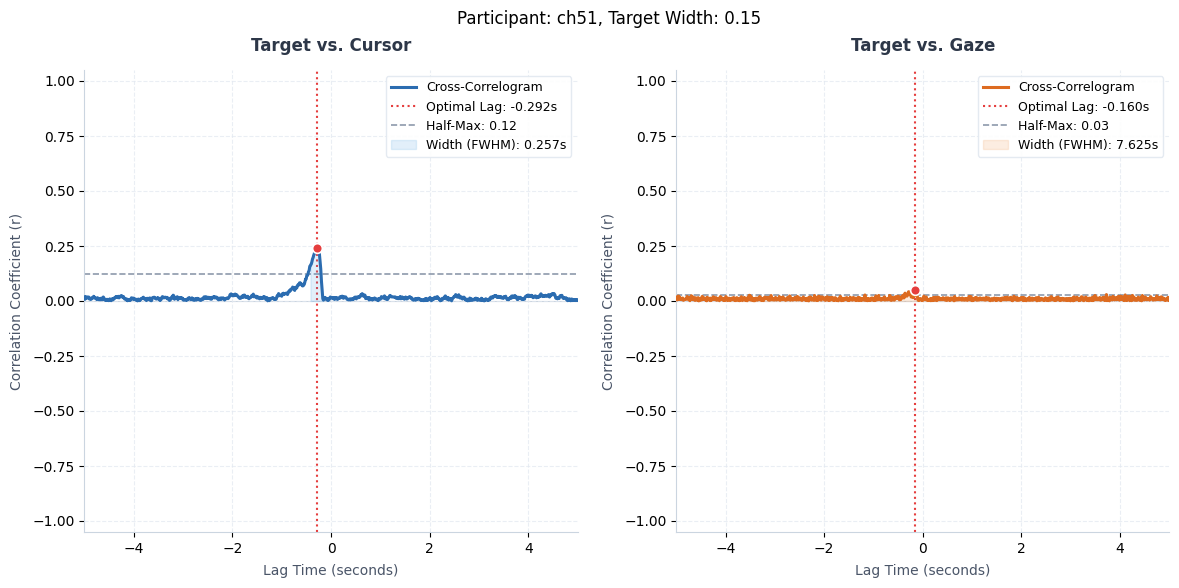

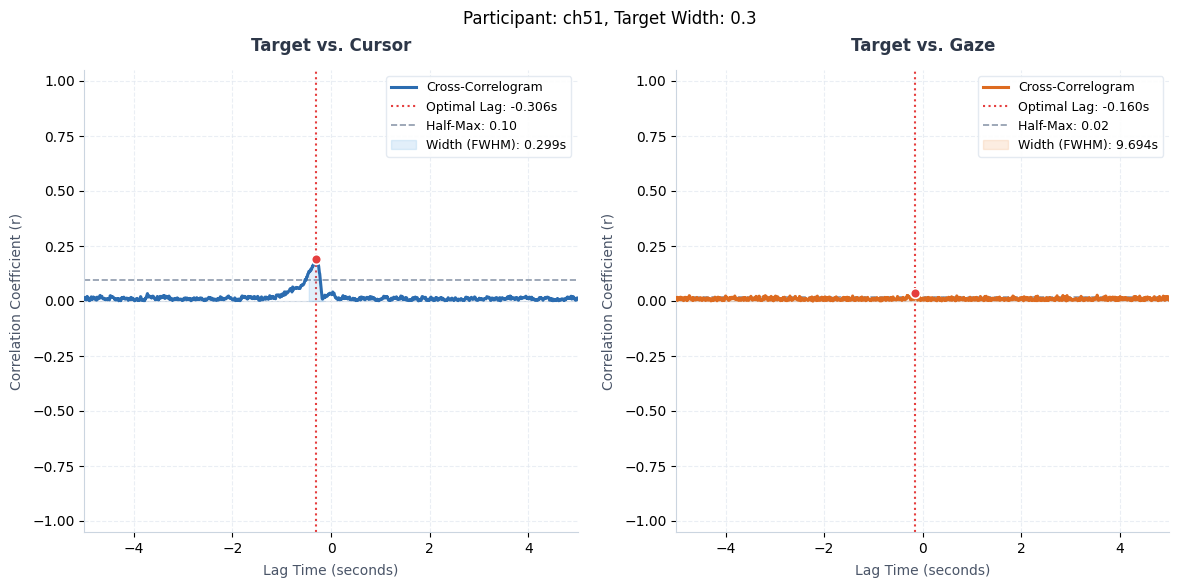

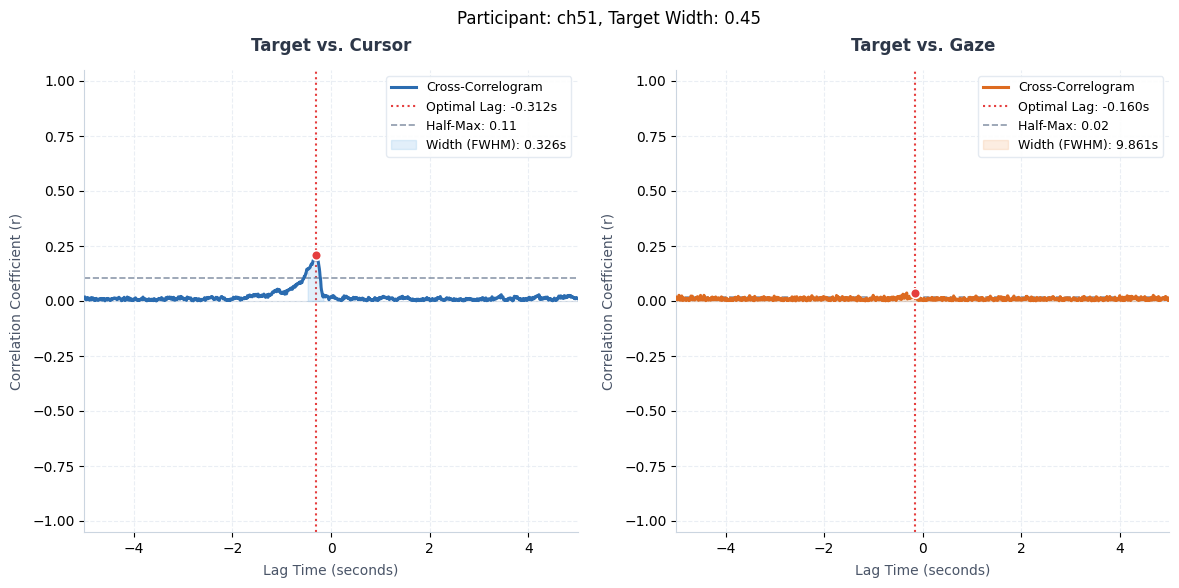

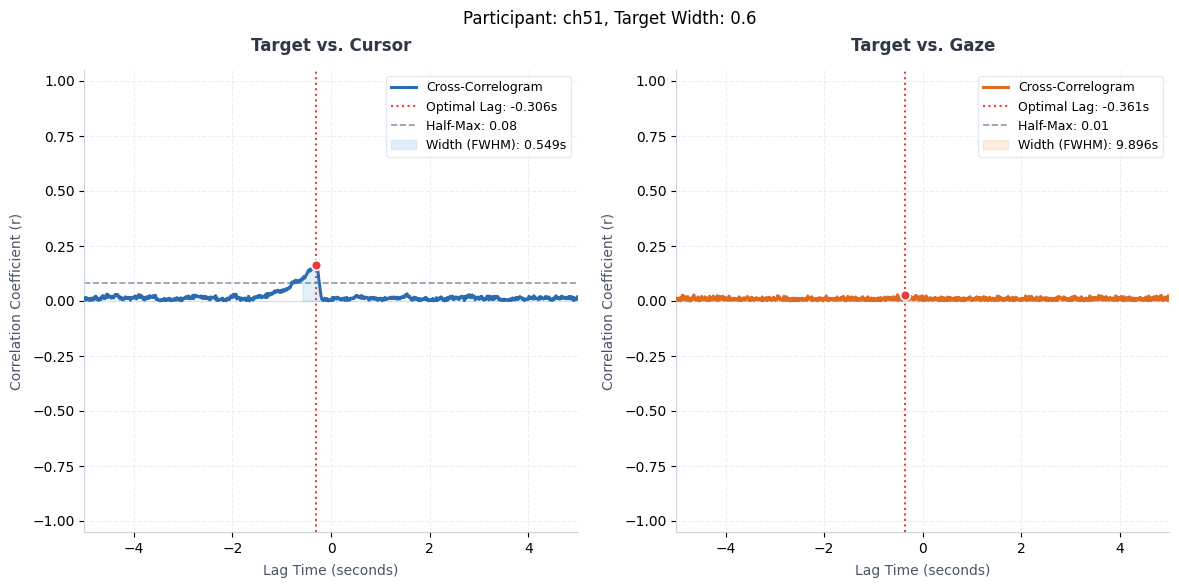

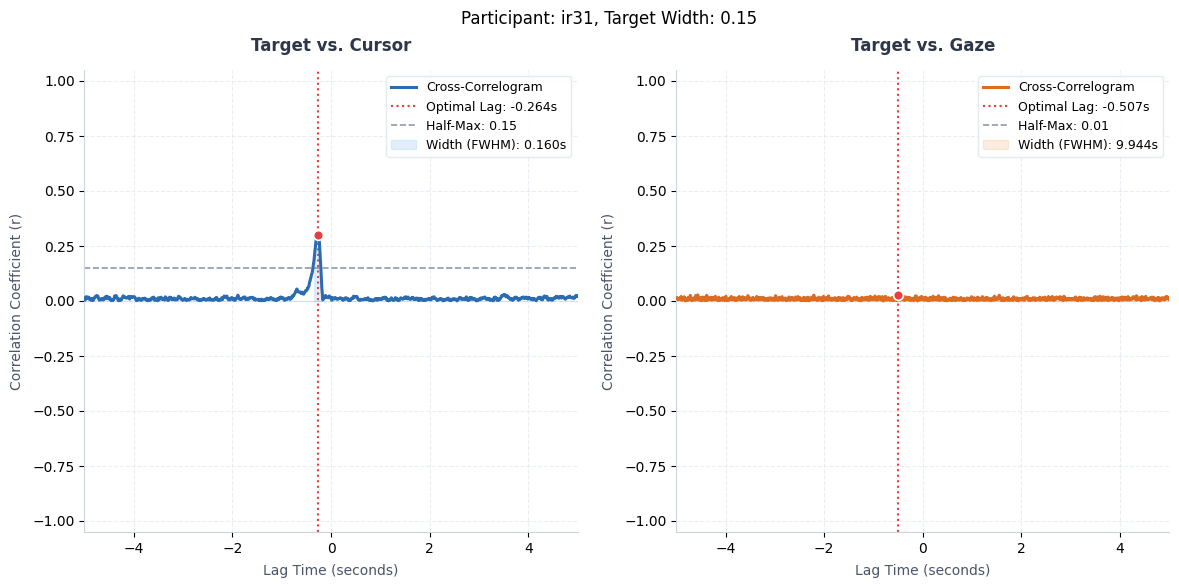

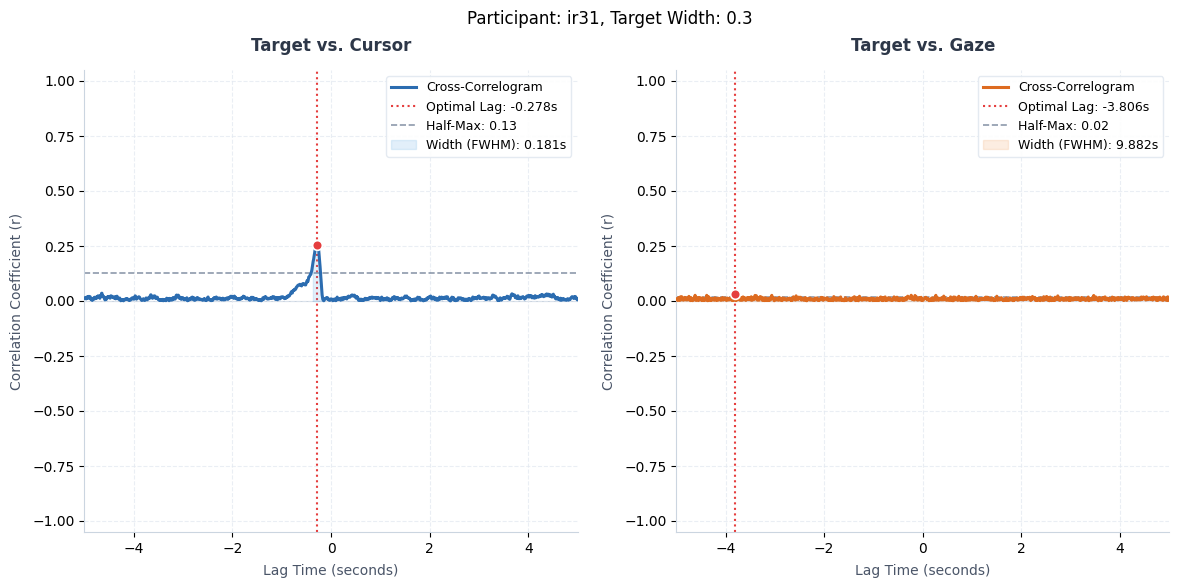

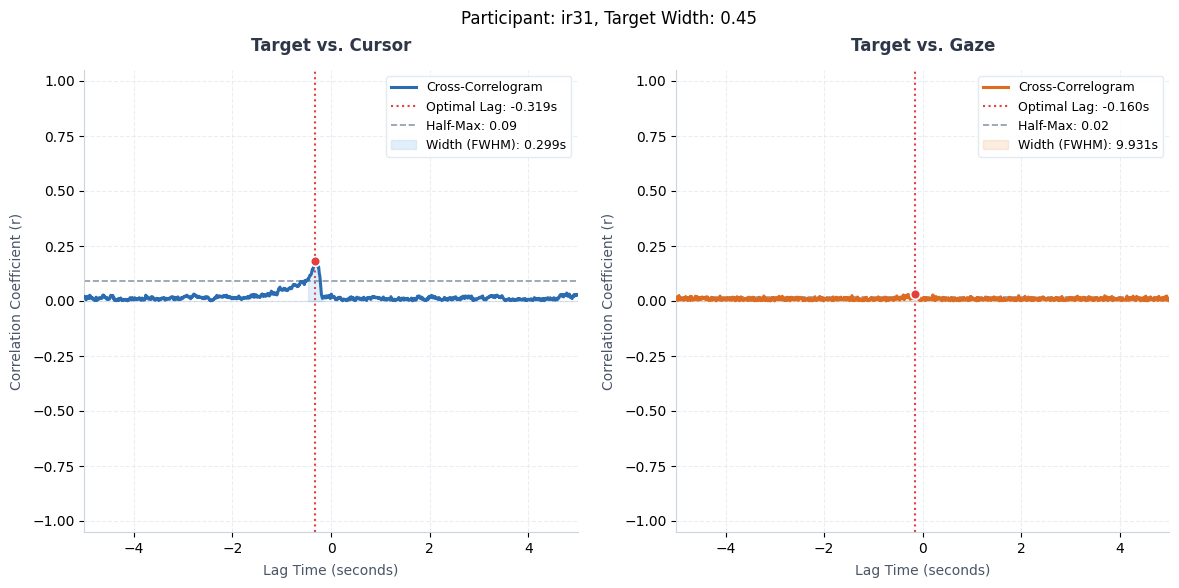

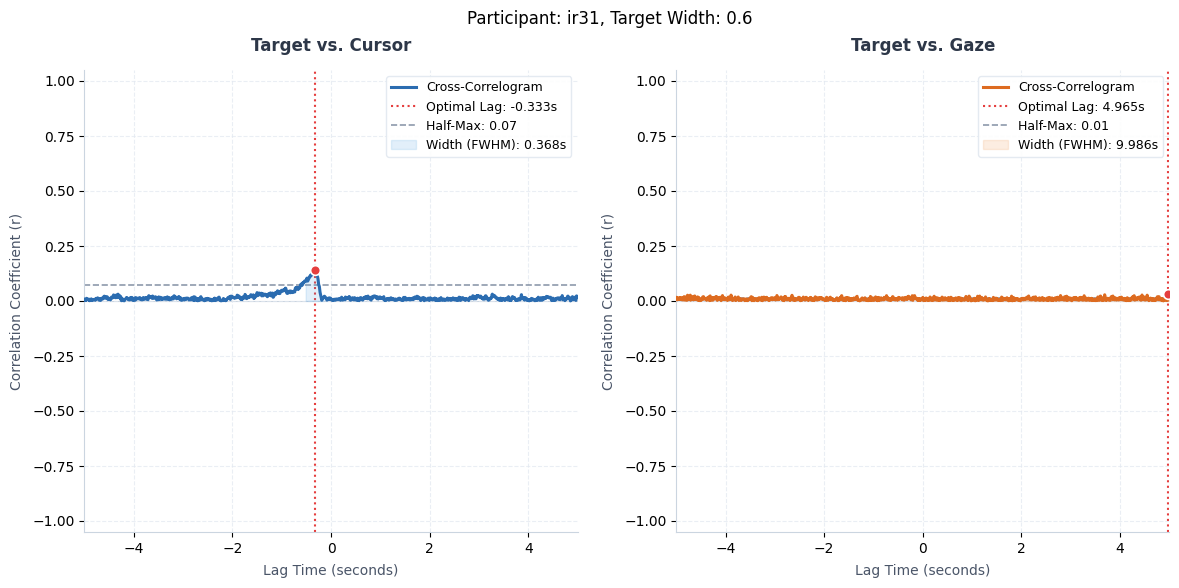

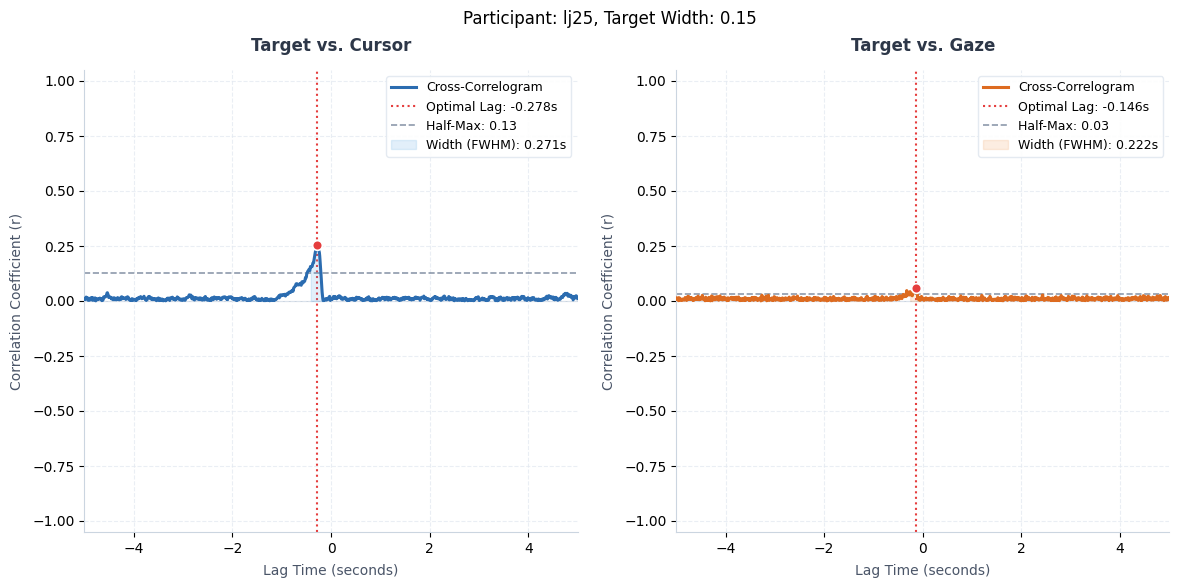

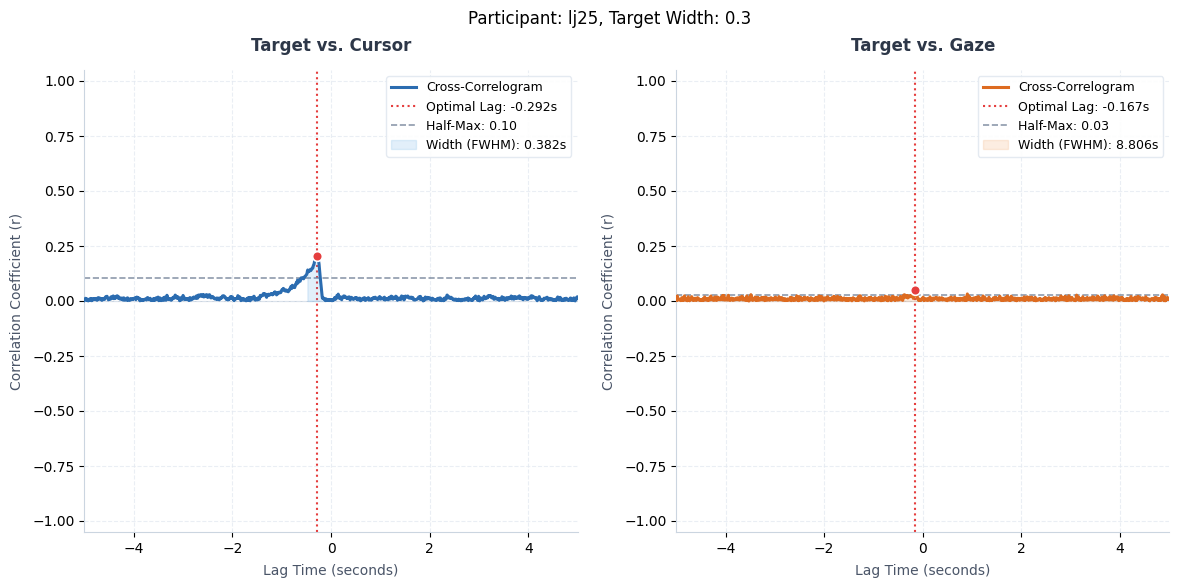

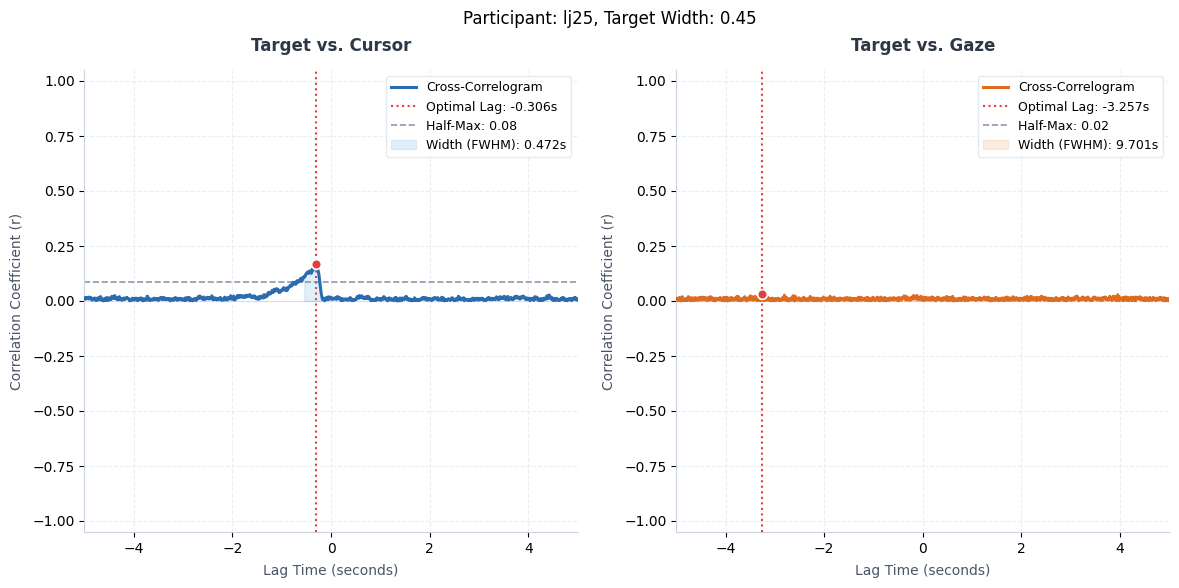

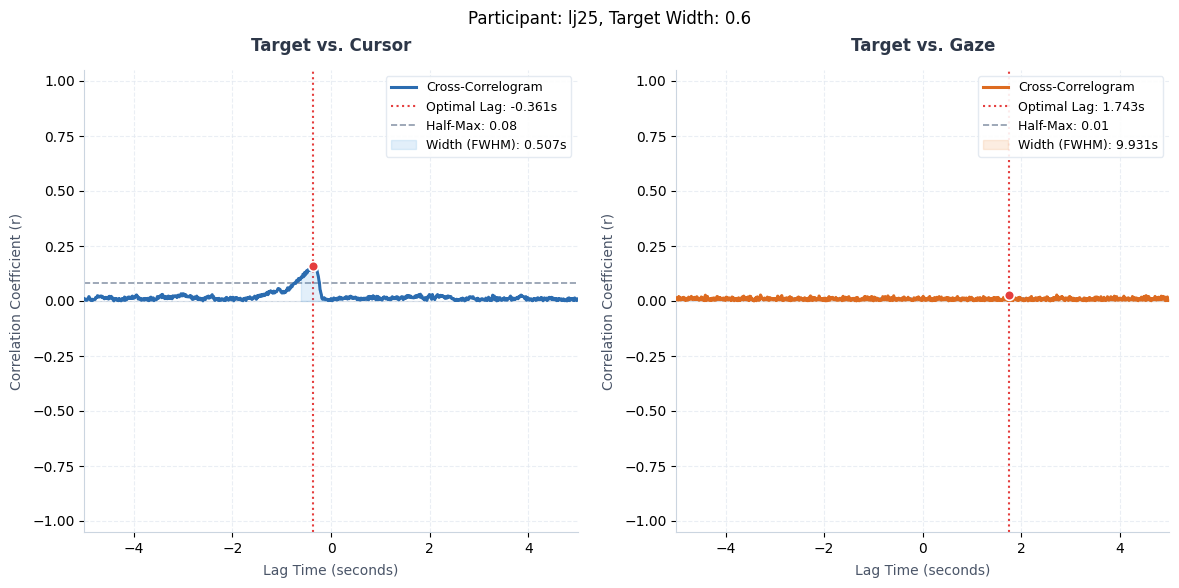

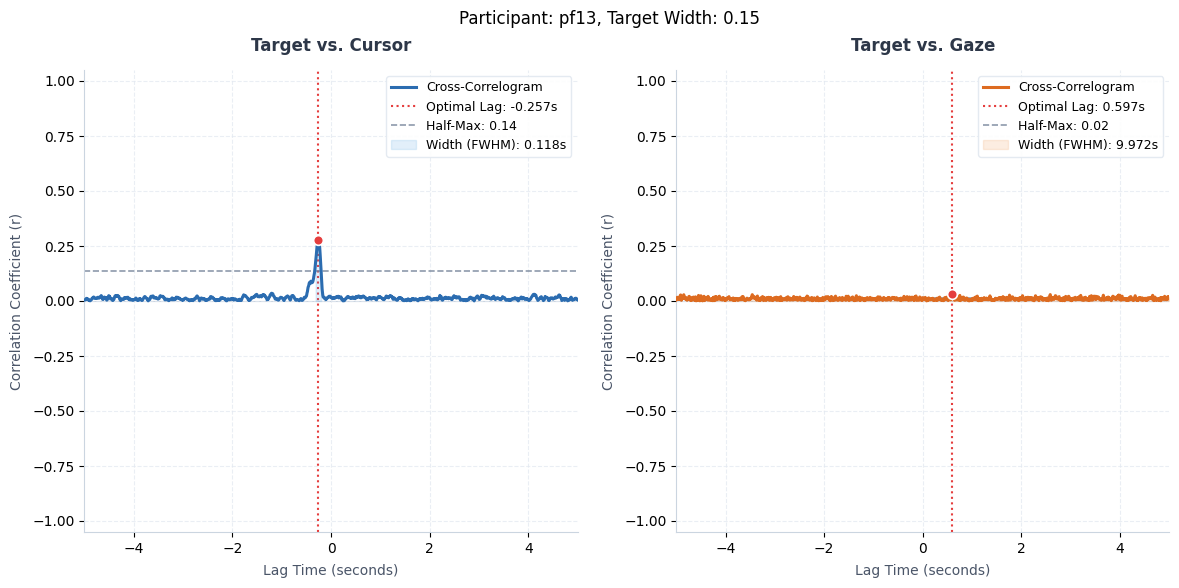

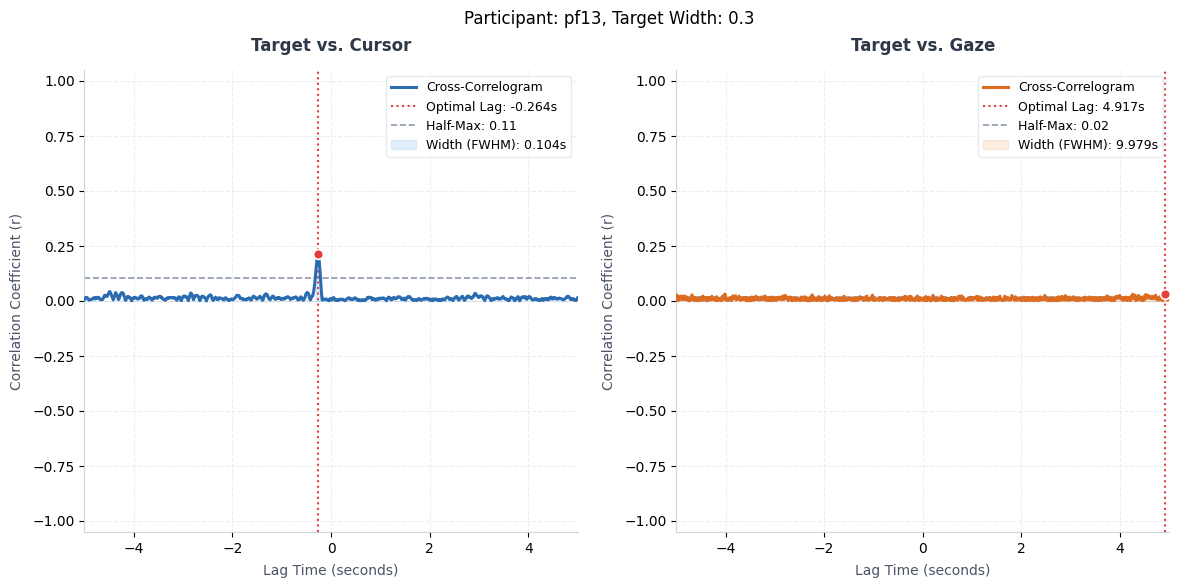

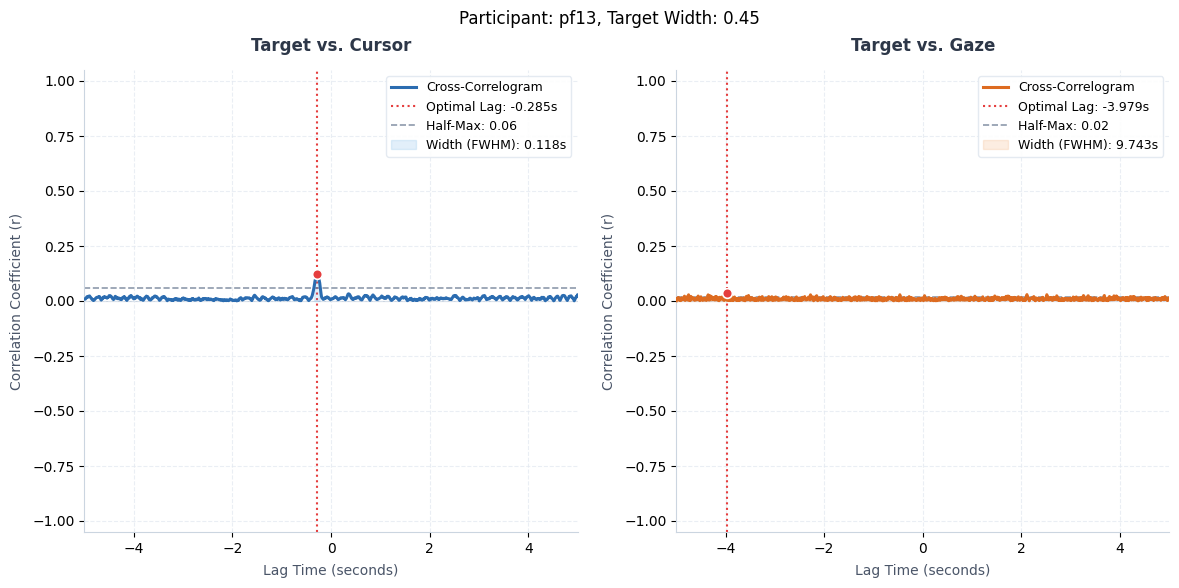

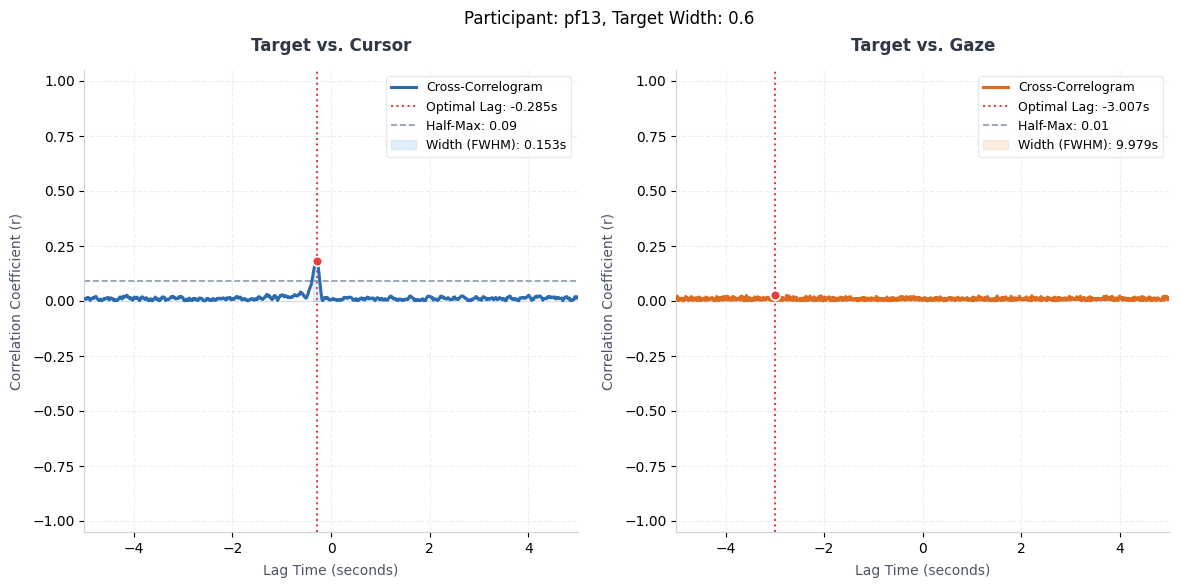

In [105]:
# plot cross correlogram for all participants and target widths (cursor metrics)
for participant_id, participant_data in continuous_metrics.groupby('participant_id'):
    for target_width, row in participant_data.groupby('target_width'):
        # to fix. plots only show the cursor metrics, gaze subplot is empty
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        plt.suptitle(f'Participant: {participant_id}, Target Width: {target_width}')
        plot_cross_correlogram(
            fig = fig,
            axes = axes[0],
            lags = row['lags_cursor'].iloc[0],
            correlation_scores = row['correlation_scores_cursor'].iloc[0],
            optimal_lag_seconds = row['lag_cursor'].iloc[0],
            peak_correlation = row['peak_cursor'].iloc[0],
            width = row['width_cursor'].iloc[0],
            signal_name='Cursor'
        )
        # plot gaze next to cursor for comparison
        plot_cross_correlogram(
            fig = fig,
            axes = axes[1],
            lags = row['lags_gaze'].iloc[0],
            correlation_scores = row['correlation_scores_gaze'].iloc[0],
            optimal_lag_seconds = row['lag_gaze'].iloc[0],
            peak_correlation = row['peak_gaze'].iloc[0],
            width = row['width_gaze'].iloc[0],
            signal_name='Gaze'
        )
        plt.show()

# example_participant = continuous_metrics['participant_id'].iloc[8]
# example_target_width = continuous_metrics['target_width'].iloc[0]
# example_row = continuous_metrics[
#     (continuous_metrics['participant_id'] == example_participant) &
#     (continuous_metrics['target_width'] == example_target_width)
# ].iloc[0]
# plot_cross_correlogram(
#     example_row['lags_cursor'],
#     example_row['correlation_scores_cursor'],
#     example_row['lag_cursor'],
#     example_row['peak_cursor'],
#     example_row['width_cursor']
# )